<a href="https://colab.research.google.com/github/bhargav210708/EDA-PROJECT/blob/main/Exp2_14_07_26(25BDS0152).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
sales_data = {
    'Region': [
        'Middle East and North Africa',
        'North America',
        'Middle East and North Africa',
        'Asia',
        'Sub-Saharan Africa',
    ],
    'Country': ['Libya', 'Canada', 'Libya', 'Japan', 'Chad'],
    'Item Type': [
        'Cosmetics',
        'Vegetables',
        'Baby Food',
        'Baby Food',
        'Fruits',
    ],
    'Sales Channel': ['Offline', 'Online', 'Offline', 'Offline', 'Offline'],
    'Units Sold': [8446, 3018, 1517, 3322, 9845],
    'Unit Price': [437.20, 154.06, 255.28, 255.28, 9.33],
    'Total Revenue': [3692591.20, 464953.08, 387259.76, 848039.16, 91853.85],
    'Total Profit': [1468506.02, 190526.34, 145419.62, 318445.92, 23726.45],
}
df = pd.DataFrame(sales_data)
print(df)

                         Region Country   Item Type Sales Channel  Units Sold  \
0  Middle East and North Africa   Libya   Cosmetics       Offline        8446   
1                 North America  Canada  Vegetables        Online        3018   
2  Middle East and North Africa   Libya   Baby Food       Offline        1517   
3                          Asia   Japan   Baby Food       Offline        3322   
4            Sub-Saharan Africa    Chad      Fruits       Offline        9845   

   Unit Price  Total Revenue  Total Profit  
0      437.20     3692591.20    1468506.02  
1      154.06      464953.08     190526.34  
2      255.28      387259.76     145419.62  
3      255.28      848039.16     318445.92  
4        9.33       91853.85      23726.45  


In [9]:
import io
import pandas as pd
csv_data = """Region,Country,Item Type,Sales Channel,Units Sold,Total Revenue,Total Profit
Middle East and North Africa,Libya,Cosmetics,Offline,8446,3692591.20,1468506.02
North America,Canada,Vegetables,Online,3018,464953.08,190526.34
Middle East and North Africa,Libya,Baby Food,Offline,1517,387259.76,145419.62
Asia,Japan,Baby Food,Offline,3322,848039.16,318445.92
Sub-Saharan Africa,Chad,Fruits,Offline,9845,91853.85,23726.45
"""
df = pd.read_csv(io.StringIO(csv_data))
print(df)

                         Region Country   Item Type Sales Channel  Units Sold  \
0  Middle East and North Africa   Libya   Cosmetics       Offline        8446   
1                 North America  Canada  Vegetables        Online        3018   
2  Middle East and North Africa   Libya   Baby Food       Offline        1517   
3                          Asia   Japan   Baby Food       Offline        3322   
4            Sub-Saharan Africa    Chad      Fruits       Offline        9845   

   Total Revenue  Total Profit  
0     3692591.20    1468506.02  
1      464953.08     190526.34  
2      387259.76     145419.62  
3      848039.16     318445.92  
4       91853.85      23726.45  


In [10]:
df.describe()

,Units Sold,Total Revenue,Total Profit
count,5.000000,5.000000e+00,5.000000e+00
mean,5229.600000,1.096939e+06,4.293249e+05
std,3672.895901,1.475856e+06,5.904085e+05
min,1517.000000,9.185385e+04,2.372645e+04
25%,3018.000000,3.872598e+05,1.454196e+05
50%,3322.000000,4.649531e+05,1.905263e+05
75%,8446.000000,8.480392e+05,3.184459e+05
max,9845.000000,3.692591e+06,1.468506e+06


In [11]:
total_rev = df['Total Revenue'].sum()
total_prof = df['Total Profit'].sum()

print(f'Total Revenue: ${total_rev:,.2f}')
print(f'Total Profit: ${total_prof:,.2f}')

Total Revenue: $5,484,697.05
Total Profit: $2,146,624.35


In [12]:
df.groupby('Item Type')['Total Profit'].sum()

,Total Profit
Item Type,
Baby Food,463865.54
Cosmetics,1468506.02
Fruits,23726.45
Vegetables,190526.34


In [13]:
df.groupby('Sales Channel')['Units Sold'].sum()

,Units Sold
Sales Channel,
Offline,23130
Online,3018


In [14]:
df[df['Units Sold'] > 3000]

,Region,Country,Item Type,Sales Channel,Units Sold,Total Revenue,Total Profit
0,Middle East and North Africa,Libya,Cosmetics,Offline,8446,3692591.20,1468506.02
1,North America,Canada,Vegetables,Online,3018,464953.08,190526.34
3,Asia,Japan,Baby Food,Offline,3322,848039.16,318445.92
4,Sub-Saharan Africa,Chad,Fruits,Offline,9845,91853.85,23726.45


<Axes: title={'center': 'Profit by Item Type'}, xlabel='Item Type'>

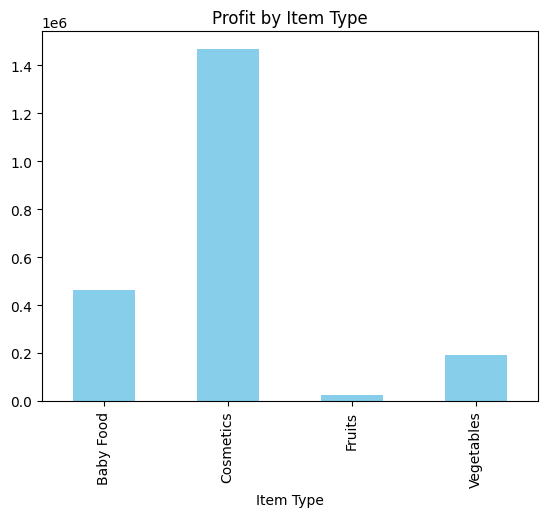

In [15]:
df.groupby('Item Type')['Total Profit'].sum().plot(
    kind='bar', color='skyblue', title='Profit by Item Type'
)

<Axes: title={'center': 'Profit by Item Type'}, xlabel='Item Type'>

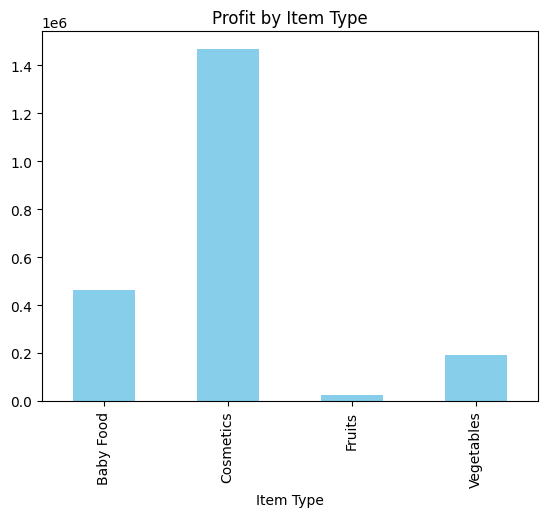

In [16]:
df.groupby('Item Type')['Total Profit'].sum().plot(
    kind='bar', color='skyblue', title='Profit by Item Type'
)

In [17]:
# Find the top 3 orders with the highest Units Sold
top_units = df.nlargest(3, "Units Sold")[["Country", "Item Type", "Units Sold", "Total Profit"]]
print(top_units)

  Country  Item Type  Units Sold  Total Profit
4    Chad     Fruits        9845      23726.45
0   Libya  Cosmetics        8446    1468506.02
3   Japan  Baby Food        3322     318445.92
